In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support
)

In [67]:
# Load & chuẩn bị dữ liệu
df = pd.read_csv("./winequality-red.csv")

X = df.drop("quality", axis=1).values
y = df["quality"].values

print("Shape X:", X.shape)
print("Quality values:", np.unique(y))

Shape X: (1599, 11)
Quality values: [3 4 5 6 7 8]


In [ ]:
# Encode nhãn ( chuyển đổi nhãn thành số từ 0 đến num_classes - 1 )
classes = np.unique(y)
class_to_idx = {c: i for i, c in enumerate(classes)}

y_idx = np.array([class_to_idx[i] for i in y])
num_classes = len(classes)

print("Class mapping:", class_to_idx)

Class mapping: {np.int64(3): 0, np.int64(4): 1, np.int64(5): 2, np.int64(6): 3, np.int64(7): 4, np.int64(8): 5}


In [69]:
# One-hot encoding
def one_hot(y, num_class):
    m = len(y)
    oh = np.zeros((m, num_class))
    oh[np.arange(m), y] = 1
    return oh


In [70]:
# Split data + Chuẩn hóa
X_train, X_test, y_train, y_test = train_test_split(
    X, y_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_idx
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Y_train = one_hot(y_train, num_classes)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1279, 11)
Test: (320, 11)


In [71]:
# Softmax & Loss function
def softmax(z):
    z = z - np.max(z)
    exp = np.exp(z)
    return exp / np.sum(exp)

def loss_function(y, y_hat):
    return -np.sum(y * np.log(y_hat + 1e-9))

In [72]:
# Train Softmax Regression (SGD)
def train_softmax(X, Y, lr=0.01, epochs=1000):
    m, n = X.shape
    k = Y.shape[1]

    Xb = np.hstack([np.ones((m,1)), X])
    theta = np.random.randn(k, n+1) * 0.01

    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for i in range(m):
            x = Xb[i].reshape(-1,1)
            y = Y[i].reshape(-1,1)

            z = theta @ x
            y_hat = softmax(z)

            loss = cross_entropy(y, y_hat)
            total_loss += loss

            grad = (y_hat - y) @ x.T
            theta -= lr * grad

        losses.append(total_loss / m)

    return theta, losses

In [73]:
# Train model
theta, losses = train_softmax(
    X_train,
    Y_train,
    lr=0.01,
    epochs=1000
)

In [74]:
# Predict
def predict(X, theta):
    m = X.shape[0]
    Xb = np.hstack([np.ones((m,1)), X])
    preds = []

    for i in range(m):
        z = theta @ Xb[i].reshape(-1,1)
        y_hat = softmax(z)
        preds.append(np.argmax(y_hat))

    return np.array(preds)

y_pred = predict(X_test, theta)

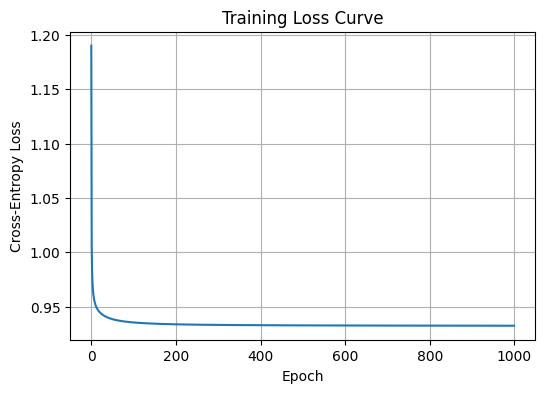

In [75]:
# Training Loss Curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.603
Precision: 0.584
Recall   : 0.603
F1-score : 0.583


c:\Users\fptsh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


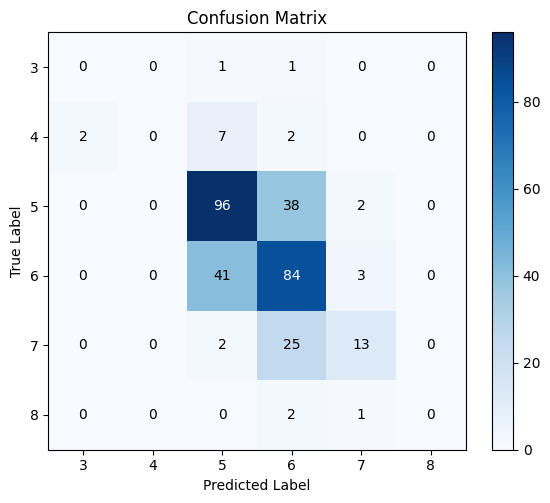

In [80]:
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()


In [78]:
TP = np.trace(cm)
FP = np.sum(cm, axis=0) - np.diag(cm)
FN = np.sum(cm, axis=1) - np.diag(cm)
TN = np.sum(cm) - (FP + FN + np.diag(cm))

TP = TP
FP = FP.sum()
FN = FN.sum()
TN = TN.sum()

print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)

TP: 193
FP: 127
FN: 127
TN: 1473


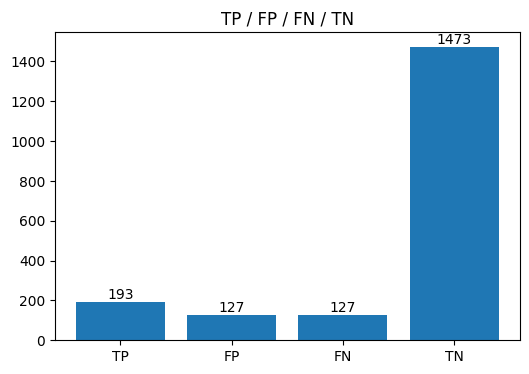

In [79]:
labels = ["TP", "FP", "FN", "TN"]
values = [TP, FP, FN, TN]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)
plt.title("TP / FP / FN / TN")

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val,
             str(val),
             ha="center",
             va="bottom")

plt.show()